In [2]:
#This second test uses voltage values for the plots instead of collected energies. This uses the ESR to generate a proper value for the collected voltage. 

#All of the imports
import sionna.rt
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

using_preview = True

In [3]:
min_distance_between_points = 15
def distance_between(a, b):
    return math.sqrt(math.pow(b[1] - a[1], 2) + math.pow(b[2]-a[2], 2))

#returns true if the position isn't close to o
def check_position_valid(pos, positions_array):
    for other_pos in positions_array:
        if(distance_between(pos, other_pos) < min_distance_between_points):
            return False
    
    return True

In [ ]:
current_scene = load_scene("3D_detailed_map_tiles/3D_Earth_blend.xml")

current_scene.frequency = 1.0001e9
num_cols = 1
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="VH")

current_scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="VH")


transmitters = []


positions_array = []

positions_array = [
    [500, -900, 27],
    [505, -900, 27],
    [550, -800, 27],
    [325, -700, 27],
    [500, -350, 30],
    [500, -310, 30],


    [-160, -290, 60],
    [-165, -290, 60],
    [0, -190, 30],
    [-510, -90, 42],
    [80, 20, 25],
    [220, 100, 37],


    [-380, 200, 40],
    [-380, 205, 40],
    [-380, 210, 40],
    [-100, 400, 20],
    [-100, 430, 20],
    [-80, 760, 75],


    [-140, 800, 25],
    [-30, 740, 75],
    [-30, 1000, 30],
    [500, 210, 27],
    [500, 300, 27], 
    [500, 305, 27]
]

powers_array = [46, 49, 0, 0, 0, 0, 
                
                46, 46, 0, 49.8, 46.8, 0, 
                
                43, 40, 49.8, 0, 0, 49.8, 
                
                49.8, 40, 0, 0, 0, 0]

for i,_position in enumerate(positions_array):
    transmitters.append(Transmitter(name=f"tx{i}_1", position=_position, display_radius=10, power_dbm=powers_array[i]))
    first_angle = random.random()*360.0
    transmitters[-1].orientation = (first_angle, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_2", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+120, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_3", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+240, 0, 0)
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")


metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

In [3]:
#Plotting reciever positions
sample_cell_positions = [
    [73, 244],
    [77, 363],
    [105,320],
    [116,270],
    [150,223],
    [173,165],
    [210,192],
    [165,283],
    [208,294]
]

for i in range(len(sample_cell_positions)):
    position = mi.Point3f([sample_cell_positions[i][0], sample_cell_positions[i][1], 1])
    position *= 5
    position -= mi.Point3f([900, 1150, 0]) #Center at middle of array
    position += mi.Point3f([0, 10, 0]) #Add offset of radio_map

    current_scene.add(Receiver(name=f"rx_{i}", position = position))


rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

radio_functions.show_sum(rm, metric="rss", show_rx=True)
current_scene.preview(radio_map=rm);


for position in sample_cell_positions:
    print(f"{radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[position[1]][position[0]])} dbm")


NameError: name 'current_scene' is not defined

z = 0


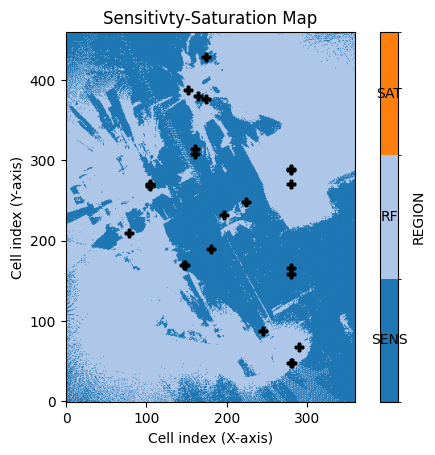

-25.3035 dbm
-25.9787 dbm
-25.0478 dbm
-35.9414 dbm
-42.4992 dbm
-43.2661 dbm
-46.0189 dbm
-30.8623 dbm
-47.2863 dbm
z = 1


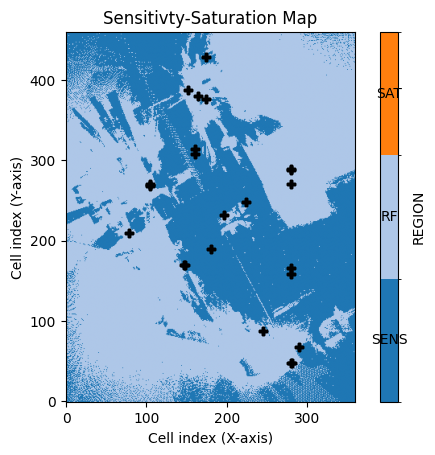

-24.2068 dbm
-25.9584 dbm
-23.9596 dbm
-35.9449 dbm
-37.3191 dbm
-39.6445 dbm
-41.195 dbm
-31.8436 dbm
-33.7004 dbm
z = 2


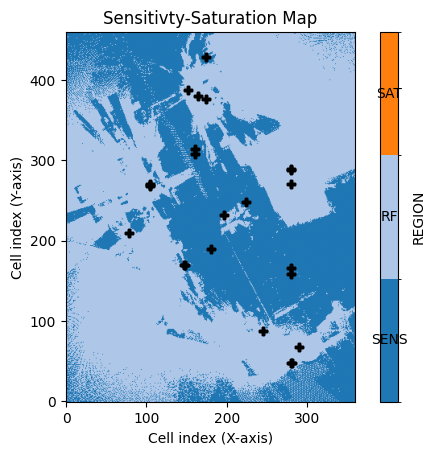

-22.7993 dbm
-26.1603 dbm
-23.6808 dbm
-29.4416 dbm
-41.253 dbm
-42.3435 dbm
-37.3855 dbm
-30.5692 dbm
-34.5759 dbm
z = 3


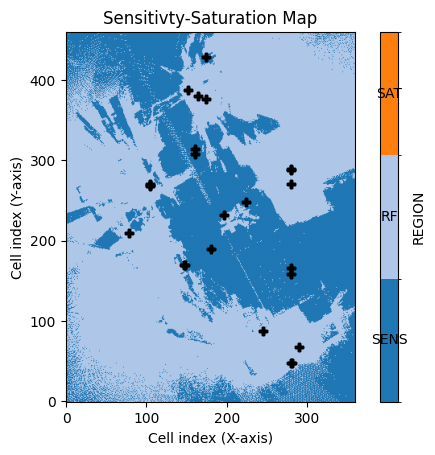

-21.8354 dbm
-25.9592 dbm
-23.2919 dbm
-29.8796 dbm
-41.4213 dbm
-43.6534 dbm
-38.0693 dbm
-30.8006 dbm
-33.5564 dbm
z = 4


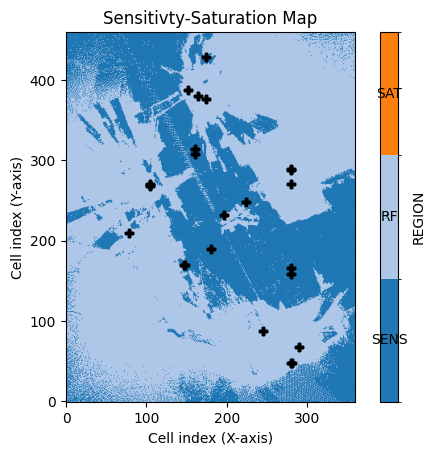

-21.2869 dbm
-24.1456 dbm
-25.3037 dbm
-32.3123 dbm
-43.7739 dbm
-33.597 dbm
-37.1689 dbm
-30.7087 dbm
-33.1625 dbm


In [ ]:
for i in range(5):
    rm = rm_solver(current_scene,
                max_depth=30,           # Maximum number of ray scene interactions
                samples_per_tx=10**7 , # If you increase: less noise, but more memory required
                cell_size=(5, 5),      # Resolution of the radio map
                center=[0, 10, i],      # Center of the radio map
                size=[1800, 2300],       # Total size of the radio map
                orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    print(f"z = {i}")    
    radio_functions.show_DC_regions(rm, metric="rss")


    for position in sample_cell_positions:
        print(f"{radio_functions.watt_to_dbm(radio_functions.sum_radio_map(rm, metric="rss")[position[1]][position[0]])} dbm")
